<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula04a_cost_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

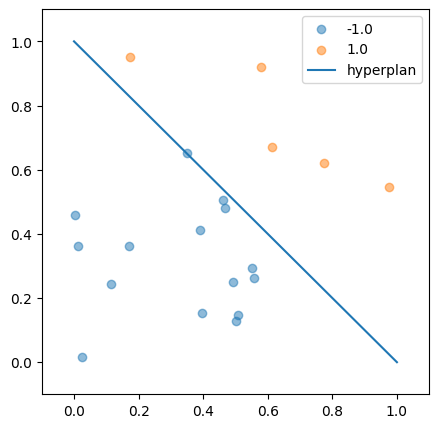

In [103]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20):
  X = np.random.rand(n,2)
  coefs = np.array([1, 1])
  intercept = 1
  labels = X @ coefs - intercept
  y = np.sign(labels)
  return X, y

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  for i in sorted(list(set(y))):
    plt.scatter(X[y==i,0], X[y==i,1], label=f"{i}", alpha=0.5)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

def plotHyperplan(vector, intercept, legend="hyperplan"):
    xs = np.array([0, 1])
    ys = -(vector[0] * xs + intercept) / vector[1]
    plt.plot(xs, ys, label=legend)
    plt.legend()

X, y = createDataset()
plotDataset(X, y)
plotHyperplan(np.array([1, 1]), -1)
plt.show()

In [104]:
from abc import ABC, abstractstaticmethod

class CostFunction(ABC):
  @abstractstaticmethod
  def get_cost(y, y_pred):
    pass
  @abstractstaticmethod
  def get_gradient(X, y, y_pred):
    pass

class WidrowHoff(CostFunction):
  @staticmethod
  def get_cost(y, y_pred):
    return np.mean((y-y_pred)**2)
  @staticmethod
  def get_gradient(X, y, y_pred):
    return X.T @ (y-y_pred)

In [105]:
from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def get_w(self, X, y):
    pass

class SGD(TrainingAlgorithm):
  def __init__(self, max_iter=1000, learning_rate=0.01, cost_function=WidrowHoff()):
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.cost_function = cost_function

  def get_w(self, X, y):
    self.w_ = np.random.random(size=X.shape[1])
    for _ in range(self.max_iter):
      y_pred = X @ self.w_
      error = y - y_pred
      self.w_ += self.learning_rate * self.cost_function.get_gradient(X, y, y_pred)
    return self.w_

Accuracy: 1.0
Weights: [-1.98404527  1.20352648  2.36049089]


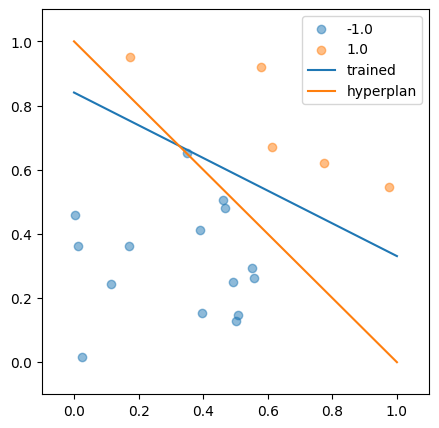

In [106]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.hstack((np.ones((X.shape[0],1)), X))

class NeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, training_algorithm=SGD()):
    self.training_algorithm = training_algorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = self.training_algorithm.get_w(X, y)
    return self

  def predict(self, X):
    X = include_bias(X)
    y_pred = X @ self.w_
    return np.sign(y_pred)

model = NeuralNetwork()
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()

In [107]:
class SmoothedSurrogate(CostFunction):
  @staticmethod
  def get_cost(y, y_pred):
    y_pred = (y_pred >= 0).astype(int)
    return np.sum(np.maximum(np.zeros(y.shape), -y * y_pred))
  @staticmethod
  def get_gradient(X, y, y_pred):
    y_pred = np.sign(y_pred)
    return X.T @ (y - y_pred)

Accuracy: 1.0
Weights: [-0.50817736  0.56431986  0.4707198 ]


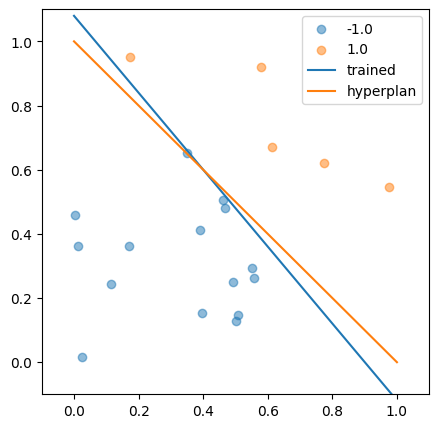

In [108]:
model = NeuralNetwork(training_algorithm=SGD(cost_function=SmoothedSurrogate()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()

Accuracy: 1.0
Weights: [-5.44082457  3.32853637  5.8209982 ]


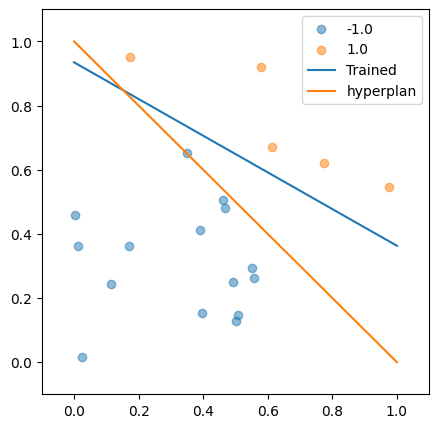

In [109]:
from scipy.special import expit

class LogLikehood(CostFunction):
  @staticmethod
  def get_cost(y, y_pred):
    y = (y>0).astype(int)
    y_pred = expit(y_pred)
    return np.sum(np.maximum(np.zeros(y.shape), 1 - y * y_pred))
  @staticmethod
  def get_gradient(X, y, y_pred):
    y = (y>0).astype(int)
    return X.T @ (y - expit(y_pred))

model = NeuralNetwork(training_algorithm=SGD(cost_function=LogLikehood()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0], legend="Trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()

Accuracy: 1.0
Weights: [-0.57855574  0.52695741  0.59010705]


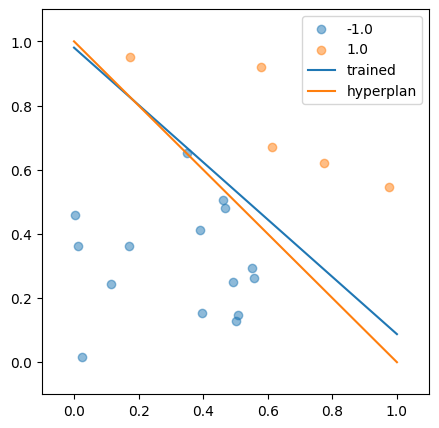

In [110]:
class HingeLoss(CostFunction):
  @staticmethod
  def get_cost(y, y_pred):
    y_pred = np.sign(y_pred)
    return np.sum(np.maximum(np.zeros(y.shape), 1 - y * y_pred))
  @staticmethod
  def get_gradient(X, y, y_pred):
    y_pred = np.sign(y_pred)
    marginal_errors = (y * y_pred) < 1
    marginal_ys = np.copy(y)
    marginal_ys[~marginal_errors] = 0
    return X.T @ marginal_ys

model = NeuralNetwork(training_algorithm=SGD(max_iter=10000, cost_function=HingeLoss()))
model.fit(X, y)
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {model.w_}")
plotDataset(X, y)
plotHyperplan(model.w_[1:], model.w_[0], legend="trained")
plotHyperplan(np.array([1, 1]), -1)
plt.show()